## 

# Zadania do samodzielnego wykonania:
1.

Proszę zaprojektować rozmyty system sterowania automatycznym podlewaniem grządki. Grządka ma 3m^2, a system podlewania może nawadniać w tempie maksymalnie 25l/dziennie, podczas, gdy zalecana ilość wody dla "zwyczajnych" warunków dla grządki w takim rozmiarze to 10l/dziennie.

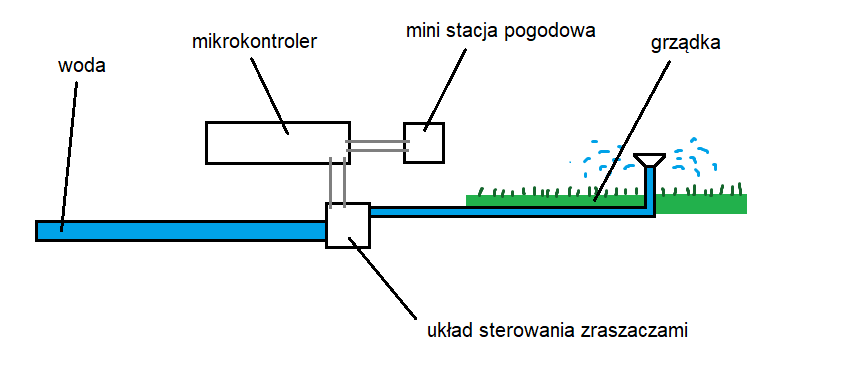

System jest sterowany elektronicznie i jest do niego podłączony higrometr (mierzący wilgotność względną w zakresie od 0% do 100%) i termometr. Temperatury są mierzone wyłącznie za dnia i znajdują się w zakresie 15°C - 35°C.Proszę zaprojektować układ rozmytego sterowania, układając reguły na podstawie następującej tabelki:

|                 | Sucho             | Przeciętnie                | Mokro      |
|-----------------|----------------------|----------------------|------------------|
| **Chłodno**     | Podlewaj średnio        | Podlewaj średnio     | Podlewaj mało    |
| **Ciepło**      | Podlewaj dużo        | Podlewaj średnio        | Podlewaj mało |
| **Gorąco**      | Podlewaj dużo | Podlewaj dużo        | Podlewaj średnio    |

Proszę samodzielnie zaproponować rozmyte funkcje przynależności i narysować je na wykresach. Proszę przedstawić heatmapę wynikowej funkcji ilości wody używanej dziennie w zależności od wilgotności i temperatury ukrytej w mechanizmie sterowania.

2.

Proszę zaproponować rozmyty system wnioskowania dla dowolnego wybranego (ale różnego od poruszanych dotychczas) problemu. Proszę wziąć pod uwagę co najmniej trzy zmienne wejściowe i każdą zmienną podzielić na co najmniej trzy zbiory rozmyte. Proszę stworzyć co najmniej 5 reguł i skomentować wyniki.

Im rzadziej Państwa pomysły będą się powtarzać, tym lepiej.

# Zadanie 1


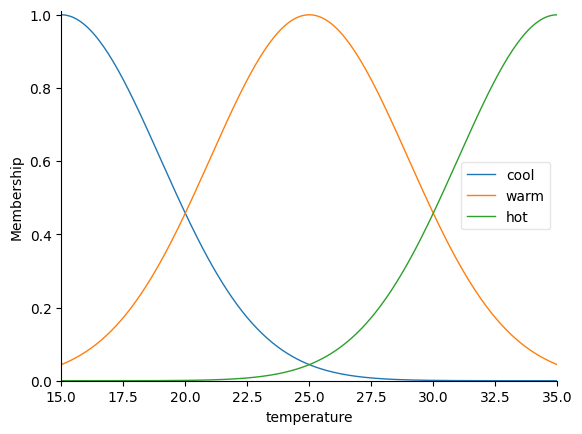

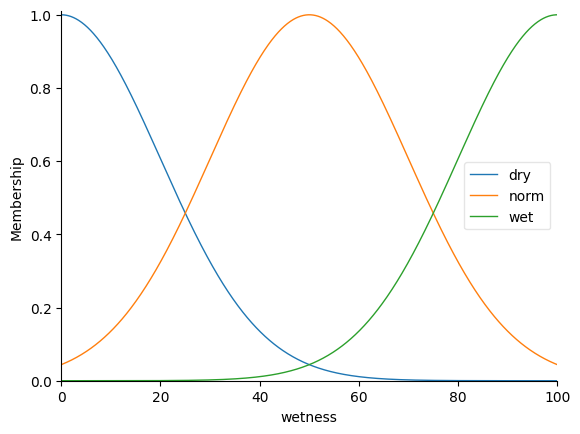

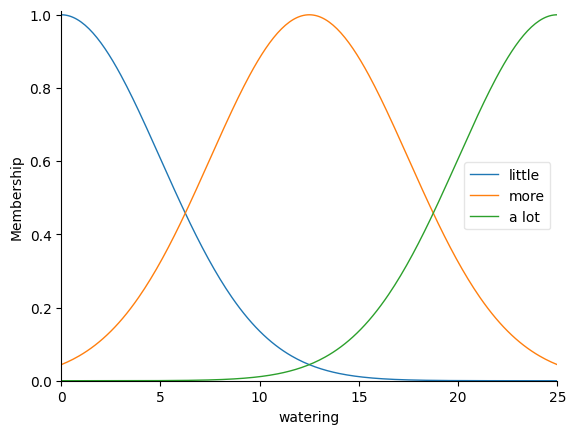

In [14]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt
from skfuzzy import control as ctrl

temperature = ctrl.Antecedent(np.arange(15, 35.1, 0.1), 'temperature')
wetness = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'wetness')
watering = ctrl.Consequent(np.arange(0, 25.1, 0.1), 'watering')

temperature['cool'] = fuzz.gaussmf(temperature.universe, 15, 4)
temperature['warm'] = fuzz.gaussmf(temperature.universe, 25, 4)
temperature['hot'] = fuzz.gaussmf(temperature.universe, 35, 4)

wetness['dry'] = fuzz.gaussmf(wetness.universe, 0, 20)
wetness['norm'] = fuzz.gaussmf(wetness.universe, 50, 20)
wetness['wet'] = fuzz.gaussmf(wetness.universe, 100, 20)

watering['little'] = fuzz.gaussmf(watering.universe, 0, 5) 
watering['more'] = fuzz.gaussmf(watering.universe, 12.5, 5) 
watering['a lot'] = fuzz.gaussmf(watering.universe, 25, 5)

temperature.view()
wetness.view()
watering.view()

In [19]:
# teraz stwórzmy zestaw zasad:

rule1 = ctrl.Rule(temperature['cool'] & wetness['dry'], watering['more']) 
rule2 = ctrl.Rule(temperature['cool'] & wetness['norm'], watering['more']) 
rule3 = ctrl.Rule(temperature['cool'] & wetness['wet'], watering['little']) 

rule4 = ctrl.Rule(temperature['warm'] & wetness['dry'], watering['a lot']) 
rule5 = ctrl.Rule(temperature['warm'] & wetness['norm'], watering['more']) 
rule6 = ctrl.Rule(temperature['warm'] & wetness['wet'], watering['little']) 

rule7 = ctrl.Rule(temperature['hot'] & wetness['dry'], watering['a lot']) 
rule8 = ctrl.Rule(temperature['hot'] & wetness['norm'], watering['a lot']) 
rule9 = ctrl.Rule(temperature['hot'] & wetness['wet'], watering['more']) 

# Tworzymy system sterowania z podanych reguł
control_system = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])

# Tworzymy symulację systemu sterowania – tu będziemy podawać konkretne wartości wejściowe
model = ctrl.ControlSystemSimulation(control_system)

Model proponuje liczbę litrów wody:  14.176174394112763


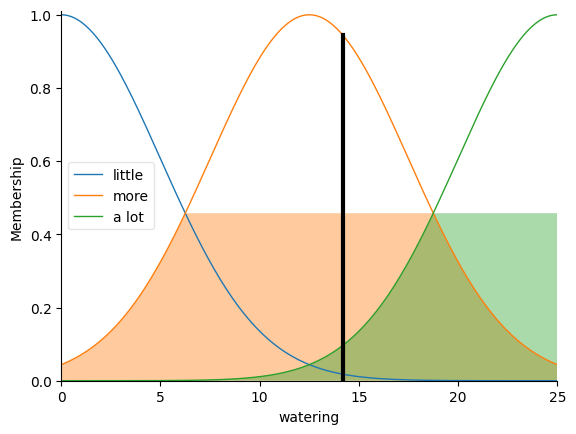

In [16]:
# możemy już przejść do faktycznego wykorzystywania wyniku
model.input['temperature'] = 20
model.input['wetness'] = 10

# oblicz:
model.compute()

# wypisz wynik i przedstaw wynik graficznie:
print('Model proponuje liczbę litrów wody: ',(model.output['watering']))
watering.view(sim=model)

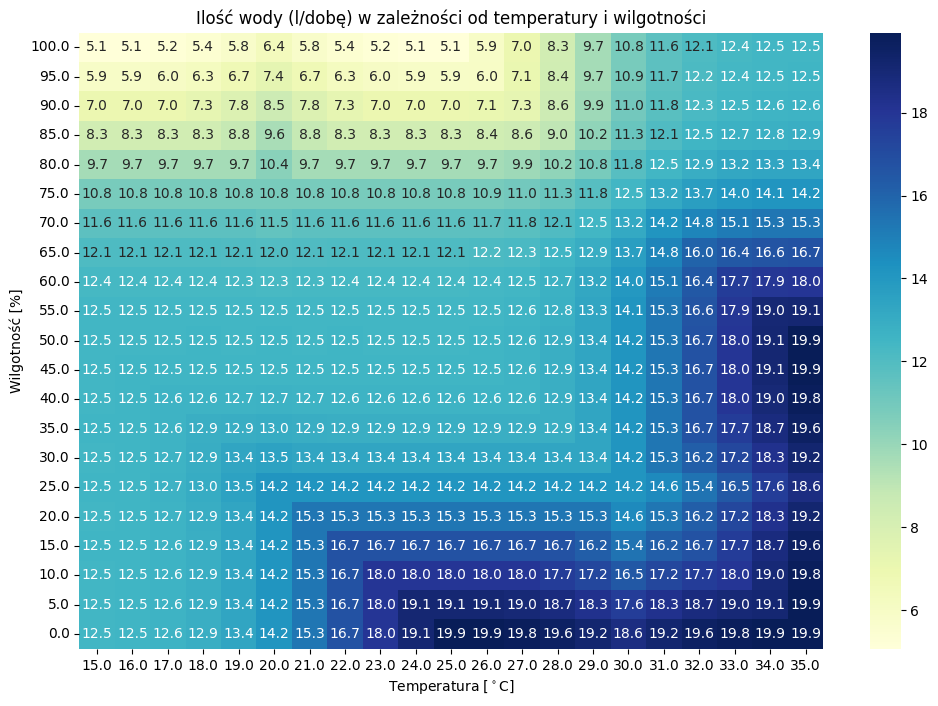

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model = ctrl.ControlSystemSimulation(control_system)

t_range = np.arange(15, 35.1, 1)  
w_range = np.arange(0, 100.1, 5)   

z = np.zeros((len(w_range), len(t_range)))

for i, w in enumerate(w_range):
    for j, t in enumerate(t_range):
        model.input['temperature'] = t
        model.input['wetness'] = w
        model.compute()
        
        z[i, j] = model.output['watering']

plt.figure(figsize=(12, 8))
df_plot = pd.DataFrame(z, index=w_range, columns=t_range)

sns.heatmap(df_plot, annot=True, fmt=".1f", cmap='YlGnBu')
plt.title('Ilość wody (l/dobę) w zależności od temperatury i wilgotności')
plt.xlabel('Temperatura [$^\circ$C]')
plt.ylabel('Wilgotność [%]')
plt.gca().invert_yaxis() 
plt.show()

# Zadanie 2

Sugerowana ocena: 3.44


C:\Python39\lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


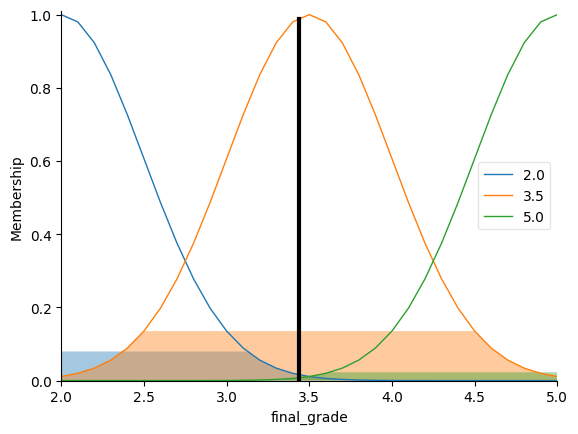

In [18]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# 1. Definicja uniwersów
attendance = ctrl.Antecedent(np.arange(0, 101, 1), 'attendance')
assignments = ctrl.Antecedent(np.arange(0, 101, 1), 'assignments')
exam = ctrl.Antecedent(np.arange(0, 101, 1), 'exam')
final_grade = ctrl.Consequent(np.arange(2, 5.1, 0.1), 'final_grade')

# 2. Funkcje Gaussa (sigma dobrana dla płynnych przejść)
attendance['low'] = fuzz.gaussmf(attendance.universe, 0, 20)
attendance['mid'] = fuzz.gaussmf(attendance.universe, 50, 20)
attendance['high'] = fuzz.gaussmf(attendance.universe, 100, 20)

assignments['poor'] = fuzz.gaussmf(assignments.universe, 0, 20)
assignments['good'] = fuzz.gaussmf(assignments.universe, 50, 20)
assignments['excellent'] = fuzz.gaussmf(assignments.universe, 100, 20)

exam['failed'] = fuzz.gaussmf(exam.universe, 0, 20)
exam['fair'] = fuzz.gaussmf(exam.universe, 50, 20)
exam['great'] = fuzz.gaussmf(exam.universe, 100, 20)

# Ocena końcowa: 2.0 (ndst), 3.5 (dst+), 5.0 (bdb)
final_grade['2.0'] = fuzz.gaussmf(final_grade.universe, 2.0, 0.5)
final_grade['3.5'] = fuzz.gaussmf(final_grade.universe, 3.5, 0.5)
final_grade['5.0'] = fuzz.gaussmf(final_grade.universe, 5.0, 0.5)

# 3. Reguły
r1 = ctrl.Rule(exam['great'] & attendance['high'], final_grade['5.0'])
r2 = ctrl.Rule(exam['failed'], final_grade['2.0'])
r3 = ctrl.Rule(assignments['excellent'] & exam['fair'], final_grade['5.0']) # Premia za aktywność
r4 = ctrl.Rule(attendance['low'] & assignments['poor'], final_grade['2.0'])
r5 = ctrl.Rule(exam['fair'] & attendance['mid'], final_grade['3.5'])

# 4. System
grading_ctrl = ctrl.ControlSystem([r1, r2, r3, r4, r5])
grading_sim = ctrl.ControlSystemSimulation(grading_ctrl)

# Test: Student z dobrą frekwencją, ale słabym egzaminem
grading_sim.input['attendance'] = 90
grading_sim.input['assignments'] = 40
grading_sim.input['exam'] = 45

grading_sim.compute()
print(f"Sugerowana ocena: {grading_sim.output['final_grade']:.2f}")
final_grade.view(sim=grading_sim)